# ⚖️ Balanceo de clases (final, sobre `src`)

**Proyecto Final — Machine Learning y Deep Learning**

> Capa **final**: usa `ml_hotel_cancellations.ml.balancing` del paquete `src/`. La versión exploratoria manual (SMOTE a mano, estilo `recursos/`) está en `notebooks/playground/05_balanceo_clases.ipynb`. Glosario: `../docs/glosario.md`.

Las clases del problema están **desbalanceadas**: hay más reservas que **no** se cancelan que canceladas. Aquí comparamos, reutilizando el código de producción, el efecto real de tres estrategias de balanceo (`baseline`, `class_weight`, `SMOTE`).

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from ml_hotel_cancellations import config
from ml_hotel_cancellations.ml.data_loader import load_and_prepare
from ml_hotel_cancellations.ml.balancing import compare

## 1. El desbalance

Nuestro objetivo `is_canceled` tiene **~37 % de cancelaciones** frente a ~63 % de reservas no canceladas. Es un desbalance **moderado** (no extremo, como el fraude o las enfermedades raras, a menudo <1 %), pero suficiente para distorsionar la lectura de las métricas:

- **La _accuracy_ engaña:** un modelo que dijera siempre "no cancela" acertaría   el ~63 % sin haber aprendido nada útil.
- **La clase minoritaria se descuida:** con menos ejemplos de cancelación, el modelo   puede detectarlas mal (bajo **recall**).

Por eso en este proyecto vigilamos sobre todo el **recall** (cancelaciones detectadas) y el **ROC-AUC** (capacidad de _ordenar_ por riesgo, independiente del umbral y robusto al desbalance). La partición ya es **estratificada**, así que conserva el ~37 % en train y test.

## 2. Comparar estrategias

`balancing.compare(...)` entrena cada **(modelo × estrategia)** con los hiperparámetros base —para **aislar el efecto del balanceo**— y devuelve sus métricas de test en un `DataFrame`. Las tres estrategias (`balancing.STRATEGIES`):

- **`baseline`** — sin balanceo.
- **`class_weight`** — reponderación _cost-sensitive_: `class_weight='balanced'` en   los modelos de scikit-learn y `scale_pos_weight` en XGBoost. No toca los datos, solo   penaliza más los errores en la clase minoritaria.
- **`SMOTE`** — sobremuestreo sintético de la minoritaria, aplicado **solo en   entrenamiento** (dentro del `Pipeline` de imbalanced-learn) para no inflar el test.

_(Entrena varios modelos × 3 estrategias: tarda un par de minutos.)_

In [2]:
X_train, X_test, y_train, y_test = load_and_prepare()

# Proporción de clases en train (~37 % cancelaciones)
print('Proporción de clases (train):')
print(y_train.value_counts(normalize=True).sort_index().round(3))

Proporción de clases (train):
is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64


In [3]:
resultados = compare(X_train, X_test, y_train, y_test)

metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
resultados.style.background_gradient(cmap='Greens', subset=['recall']).format(
    {c: '{:.3f}' for c in metricas}
)

,modelo,estrategia,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,baseline,0.825,0.806,0.695,0.746,0.906
1,Decision Tree,baseline,0.850,0.819,0.764,0.791,0.930
2,Random Forest,baseline,0.857,0.884,0.708,0.786,0.940
3,XGBoost,baseline,0.893,0.869,0.838,0.854,0.961
4,Logistic Regression,class_weight,0.819,0.731,0.809,0.768,0.906
5,Decision Tree,class_weight,0.846,0.795,0.789,0.792,0.925
6,Random Forest,class_weight,0.863,0.803,0.834,0.818,0.940
7,XGBoost,class_weight,0.892,0.852,0.858,0.855,0.961
8,Logistic Regression,SMOTE,0.820,0.734,0.807,0.769,0.906
9,Decision Tree,SMOTE,0.841,0.775,0.805,0.790,0.927


## 3. Lectura de la tabla

Ordenamos por **(modelo, estrategia)** y comparamos visualmente **recall** y **precision** entre estrategias —ahí se ve el compromiso— y, aparte, el **ROC-AUC**, que debería quedarse prácticamente igual.

In [4]:
orden = resultados.sort_values(['modelo', 'estrategia']).reset_index(drop=True)
orden.round(3)

,modelo,estrategia,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,SMOTE,0.841,0.775,0.805,0.790,0.927
1,Decision Tree,baseline,0.850,0.819,0.764,0.791,0.930
2,Decision Tree,class_weight,0.846,0.795,0.789,0.792,0.925
3,Logistic Regression,SMOTE,0.820,0.734,0.807,0.769,0.906
4,Logistic Regression,baseline,0.825,0.806,0.695,0.746,0.906
5,Logistic Regression,class_weight,0.819,0.731,0.809,0.768,0.906
6,Random Forest,SMOTE,0.864,0.817,0.815,0.816,0.940
7,Random Forest,baseline,0.857,0.884,0.708,0.786,0.940
8,Random Forest,class_weight,0.863,0.803,0.834,0.818,0.940
9,XGBoost,SMOTE,0.893,0.863,0.846,0.854,0.961


### 3.1 Recall vs precision por estrategia

Cada panel agrupa los modelos; el color es la estrategia. Se aprecia cómo `class_weight` y `SMOTE` **suben el recall** y, a la vez, **bajan la precision**.

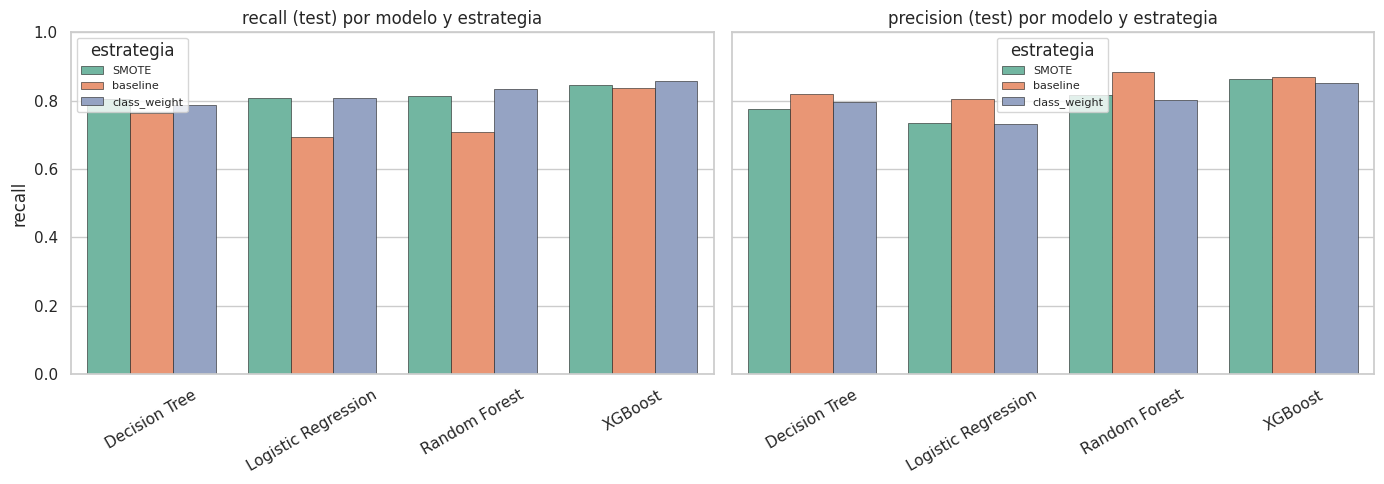

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metrica in zip(axes, ['recall', 'precision']):
    sns.barplot(data=orden, x='modelo', y=metrica, hue='estrategia',
                ax=ax, palette='Set2', edgecolor='k', linewidth=0.4)
    ax.set_title(f'{metrica} (test) por modelo y estrategia')
    ax.set_ylim(0, 1); ax.set_xlabel(''); ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='estrategia', fontsize=8)
plt.tight_layout(); plt.show()

### 3.2 ROC-AUC: casi invariante al balanceo

El **ROC-AUC** apenas se mueve entre estrategias: balancear no mejora la capacidad de _ordenar_ por riesgo, solo desplaza el compromiso del umbral.

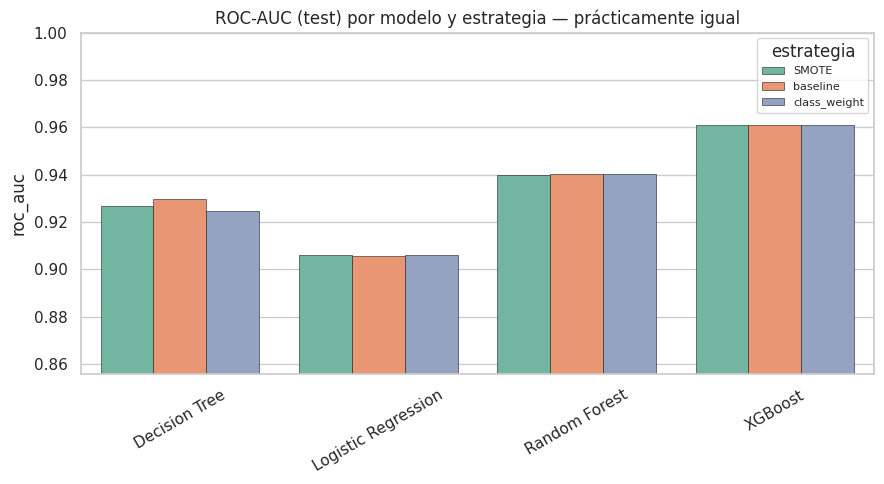

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=orden, x='modelo', y='roc_auc', hue='estrategia',
            ax=ax, palette='Set2', edgecolor='k', linewidth=0.4)
ax.set_title('ROC-AUC (test) por modelo y estrategia — prácticamente igual')
vmin = orden['roc_auc'].min()
ax.set_ylim(max(0.0, vmin - 0.05), 1.0)  # zoom para apreciar las diferencias
ax.set_xlabel(''); ax.set_ylabel('roc_auc')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='estrategia', fontsize=8)
plt.tight_layout(); plt.show()

## 4. Conclusión

- El balanceo (`class_weight` o `SMOTE`) **sube el recall** —se detectan más   cancelaciones— a costa de **bajar la precision** (más falsas alarmas).
- El **ROC-AUC apenas cambia**: es **independiente del umbral**, así que balancear no   hace al modelo "mejor" ordenando por riesgo; solo desplaza el umbral efectivo hacia   detectar más positivos.
- Por eso el **pipeline de producción NO balancea**: nuestra métrica de selección es   el ROC-AUC, y para priorizar recall basta con **mover el umbral** de decisión.
- El balanceo es **útil solo para métricas dependientes del umbral** (recall,   precision, F1) cuando el coste de **no detectar** una cancelación supera al de una   falsa alarma (p. ej. activar _overbooking_). En desbalances **extremos** (<5 %)   estas técnicas pesan mucho más que en este caso moderado.

_Comprobación cruzada:_ el gráfico de abajo es el artefacto que genera la CLI `python -m ml_hotel_cancellations.ml.balancing` (`config.BALANCING_PLOT_PATH`), con el efecto del balanceo concentrado en XGBoost.

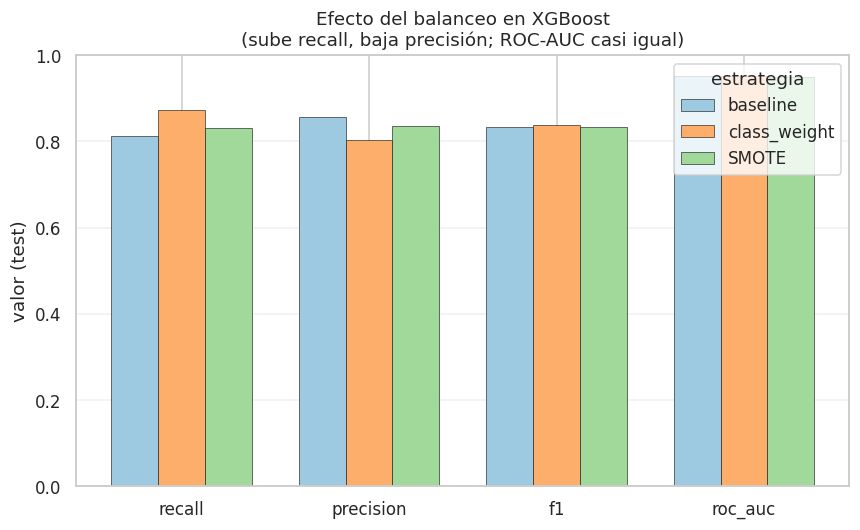

In [7]:
from IPython.display import Image, Markdown, display

if config.BALANCING_PLOT_PATH.exists():
    display(Image(filename=str(config.BALANCING_PLOT_PATH)))
else:
    display(Markdown(
        f'_(Aún no existe `{config.BALANCING_PLOT_PATH.name}`; genéralo con `python -m ml_hotel_cancellations.ml.balancing`.)_'
    ))